# 현재 작업 디렉토리(working directory)

In [54]:
import pandas as pd
import seaborn as sns
import numpy as np

In [55]:
transaction_pd = pd.read_csv(r"C:\Users\Playdata\src\jjha\data\transactions_train.csv")
customer_df = pd.read_csv(r"C:\Users\Playdata\src\jjha\data\customers.csv")
art_df = pd.read_csv(r"C:\Users\Playdata\src\jjha\data\articles.csv")

In [56]:
print(len(transaction_pd))
print(len(customer_df))
print(len(art_df))

31788324
1371980
105542


In [57]:
art_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [58]:
# transaction & customer 중복 key 컬럼 확인
print(set(transaction_pd.columns)&set(customer_df.columns))

# customer & transaction merge (key : customer id)
cust_tran_df = customer_df.merge(transaction_pd, how='inner', on = ['customer_id'])

# cust_tran_df.isna().sum()

{'customer_id'}


In [59]:
set(art_df.columns)&set(cust_tran_df.columns)
total_df = cust_tran_df.merge(art_df, how='inner', on =['article_id'])

In [60]:
# 패션 뉴스, 온라인 마케팅 등록 여부
total_df['FN'] = total_df['FN'].fillna(0)
total_df['Active'] = total_df['Active'].fillna(0)

In [47]:
# FN, ACtive 0 채우기 확인
# total_df.isna().sum()

### club_member_status 
- H&M 클럽 멤버십은 회원이 계정을 생성해 가입한 뒤, 구매·리뷰·기타 활동을 통해 포인트를 적립하고 이를 리워드로 교환하는 로열티 프로그램
- ACTIVE: 현재 클럽 멤버십이 활성화된 회원
- PRE-CREATE: 계정/멤버십이 사전 생성되었으나 완전 활성화 전 상태
- LEFT CLUB: 클럽을 탈퇴한 회원 (브랜드 완전이탈이 확정이 아님, 조금 애매함)
- NaN: 멤버십 상태 정보가 없는 결측값

**H&M club_member_status NaN

오프라인 구매만 한 고객,
멤버십 상태 수집 전 가입자,
데이터 병합 과정에서 상태 누락,
멤버십과 무관한 일반 고객

In [61]:
# club_member_status na값 삭제
# 62,000(NA) / 30,000,000 ≈ 0.21%
total_df['club_member_status'] = total_df['club_member_status'].replace('nan',np.nan)
total_df = total_df.dropna(subset=['club_member_status'])

#### 패션 뉴스레터 수신 빈도 
- array(['NONE', 'Regularly', nan, 'Monthly'], dtype=object)

| 값         | 의미              |
| --------- | --------------- |
| NONE      | 수신 안 함 /뉴스레터 거부자와 정보 없음 고객을 같은 그룹|
| Monthly   | 월 1회 수신         |
| Regularly | 정기 수신 (월 1회 이상) |
| NaN       | 정보 없음           |


In [62]:
total_df['fashion_news_frequency'] = total_df['fashion_news_frequency'].fillna('UNKNOWN')
print(total_df['fashion_news_frequency'].unique())
total_df.isna().sum()

['NONE' 'Regularly' 'UNKNOWN' 'Monthly']


customer_id                          0
FN                                   0
Active                               0
club_member_status                   0
fashion_news_frequency               0
age                             126598
postal_code                          0
t_dat                                0
article_id                           0
price                                0
sales_channel_id                     0
product_code                         0
prod_name                            0
product_type_no                      0
product_type_name                    0
product_group_name                   0
graphical_appearance_no              0
graphical_appearance_name            0
colour_group_code                    0
colour_group_name                    0
perceived_colour_value_id            0
perceived_colour_value_name          0
perceived_colour_master_id           0
perceived_colour_master_name         0
department_no                        0
department_name          

### 나이 (결측치 알수없음으로 채움)
- min(10대), max(90대) - 이상치인지 확인 필요
 (16.0, 99.0)


In [63]:
min(total_df['age']), max(total_df['age'])

(16.0, 99.0)

In [64]:
total_df[total_df['age']>=90].value_counts() # 1393건

customer_id                                                       FN   Active  club_member_status  fashion_news_frequency  age   postal_code                                                       t_dat       article_id  price     sales_channel_id  product_code  prod_name                    product_type_no  product_type_name  product_group_name  graphical_appearance_no  graphical_appearance_name  colour_group_code  colour_group_name  perceived_colour_value_id  perceived_colour_value_name  perceived_colour_master_id  perceived_colour_master_name  department_no  department_name       index_code  index_name          index_group_no  index_group_name  section_no  section_name                    garment_group_no  garment_group_name  detail_desc                                                                                                                                                                                                                   
bc870dbac4a150f6e5cf8e1d71e59d77d3da3f171d

In [65]:
bins = [0, 19, 29, 39, 49, 59, 69, 100]
labels = ['10대 미만', '10대', '20대', '30대', '40대', '50대', '60대 이상']
total_df['age_cut'] = pd.cut(total_df['age'], bins=bins, labels=labels, right=True).astype('str')
type(total_df['age_cut'])
total_df['age_cut'] = total_df['age_cut'].str.replace('nan', 'UNKNOWN')

In [66]:
total_df['club_member_status'].unique()

array(['ACTIVE', 'PRE-CREATE', 'LEFT CLUB'], dtype=object)

In [67]:
total_df['age_cut'].unique()

array(['30대', '10대', '40대', '20대', '60대 이상', '50대', '10대 미만', 'UNKNOWN'],
      dtype=object)

In [68]:
total_df['age_cut'].value_counts()

age_cut
10대        13039351
20대         6416888
40대         5130097
30대         4901185
50대         1201949
10대 미만       690192
60대 이상       219899
UNKNOWN      126598
Name: count, dtype: int64

In [69]:
total_df.columns

Index(['customer_id', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code', 't_dat', 'article_id',
       'price', 'sales_channel_id', 'product_code', 'prod_name',
       'product_type_no', 'product_type_name', 'product_group_name',
       'graphical_appearance_no', 'graphical_appearance_name',
       'colour_group_code', 'colour_group_name', 'perceived_colour_value_id',
       'perceived_colour_value_name', 'perceived_colour_master_id',
       'perceived_colour_master_name', 'department_no', 'department_name',
       'index_code', 'index_name', 'index_group_no', 'index_group_name',
       'section_no', 'section_name', 'garment_group_no', 'garment_group_name',
       'detail_desc', 'age_cut'],
      dtype='object')

In [70]:
import os
os.chdir(r"C:\Users\Playdata\src\jjha\data")

customers = pd.read_csv("customers.csv")
articles = pd.read_csv("articles.csv")
transactions = pd.read_csv("transactions_train.csv")

print("로드 완료")

로드 완료


In [71]:
total_df = total_df[['customer_id', 'FN', 'club_member_status',
       'fashion_news_frequency', 'age', 't_dat', 'price', 'product_group_name','age_cut']]
EDA_columns = total_df

In [72]:
EDA_columns.head(5)

,customer_id,FN,club_member_status,fashion_news_frequency,age,t_dat,price,product_group_name,age_cut
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,30대
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,30대
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,30대
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,30대
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대


### price 값 수치 의미 (기업 미공개- 정규화된 데이터)

| 값 예시                          | 해석                      |                 |
| -------------------------- | ----------------------- | --------------- |
| `0.009`                    | 원본에서 매우 낮은 가격 → 스케일링 결과 |                 |
| `0.0278` (dataset average) | 스케일링된 평균 거래 가격          | ([ARAMDAUN][1]) |
| `0.5915` (max)             | 스케일된 가장 비싼 상품           | ([ARAMDAUN][1]) |

[1]: https://ars420.tistory.com/42?utm_source=chatgpt.com "[Kaggle] H&M Personalized Fashion Recommendations"


In [73]:
type(EDA_columns['t_dat'])
EDA_columns['transaction_dat'] = pd.to_datetime(EDA_columns['t_dat'], format="%Y-%m-%d")

In [74]:
# 평균 구매 간격
EDA_columns = EDA_columns.sort_values(['customer_id','transaction_dat'])
EDA_columns['prev_date'] = EDA_columns.groupby('customer_id')['transaction_dat'].shift(1)
EDA_columns['gap'] = (EDA_columns['transaction_dat'] - EDA_columns['prev_date']).dt.days
EDA_columns = EDA_columns.fillna(0) # 시작날은 시차 0 

# shape 출력 결과 의미

In [75]:
print(customers.shape)
print(articles.shape)
print(transactions.shape)

(1371980, 7)
(105542, 25)
(31788324, 5)


In [76]:
# 거래 데이터 불러오기
transactions = pd.read_csv(
    "transactions_train.csv",
    parse_dates=["t_dat"],
    dtype={
        "customer_id": "string",
        "article_id": "int32",
        "price": "float32",
        "sales_channel_id": "int8"
    }
)

# 고객 테이블 dtype 정리
customers["customer_id"] = customers["customer_id"].astype("string")

In [77]:
first_tx = (transactions
            .groupby("customer_id", as_index=False)["t_dat"]
            .min()
            .rename(columns={"t_dat":"first_purchase_date"}))

# customers에 first_purchase_date 붙이기
cust = customers.merge(first_tx, on="customer_id", how="left")

In [79]:
EDA_columns['t_dat'] = EDA_columns['t_dat'].astype(str)

# 1. 전체 고객 이탈 label : API 적용-> API가 90일보다 크면 이탈 (90일) + 1번 구매 후 없음

In [80]:
# API ratio = 고객 구매 주기 일수의 총합 / 거래 횟수 - 1(첫번쨰 거래 제외)

API_count = EDA_columns.groupby('customer_id').agg({
    't_dat': lambda x: x.nunique(),  # 중복 제거한 거래일 수 
    'gap': 'sum'                     # gap 합계
}).reset_index()

API_count['API ratio'] = (API_count['gap']) / (API_count['t_dat']-1)
API_count     

# # API, 신규고객 이탈 라벨링

# API
API_count['churn'] = np.where(API_count['API ratio']> 90 , 1, 0) # 이탈 - 1 / 미이탈 - 0 / 이커머스 기준 90일 (데이터리안)

# 신규고객 
API_count['only_first_tran'] = np.where(API_count['t_dat']==1,1,0) # 0인 고객들은 API 수식이 적용이 안됨

# API + 신규
API_count['total_churn'] = API_count['churn']+API_count['only_first_tran'] # api 비율 기준 + 거래가 1인 고객은 무조건 이탈
API_count

,customer_id,t_dat,gap,API ratio,churn,only_first_tran,total_churn
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,10,618.0,68.666667,0,0,0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,23,656.0,29.818182,0,0,0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,7,726.0,121.000000,1,0,1
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,1,0.0,NaN,0,1,1
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,6,670.0,134.000000,1,0,1
...,...,...,...,...,...,...,...
1356222,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,11,522.0,52.200000,0,0,0
1356223,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,19,693.0,38.500000,0,0,0
1356224,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,19,720.0,40.000000,0,0,0
1356225,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,4,78.0,26.000000,0,0,0


In [81]:
API_count['API ratio'] = API_count['API ratio'].fillna(0)
API_count.isna().sum()
API_count

,customer_id,t_dat,gap,API ratio,churn,only_first_tran,total_churn
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,10,618.0,68.666667,0,0,0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,23,656.0,29.818182,0,0,0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,7,726.0,121.000000,1,0,1
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,1,0.0,0.000000,0,1,1
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,6,670.0,134.000000,1,0,1
...,...,...,...,...,...,...,...
1356222,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,11,522.0,52.200000,0,0,0
1356223,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,19,693.0,38.500000,0,0,0
1356224,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,19,720.0,40.000000,0,0,0
1356225,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,4,78.0,26.000000,0,0,0


# 주간 신규 고객 수 (최초 구매 기준)

<Axes: title={'center': 'Weekly New Customers (by First Purchase)'}, xlabel='date'>

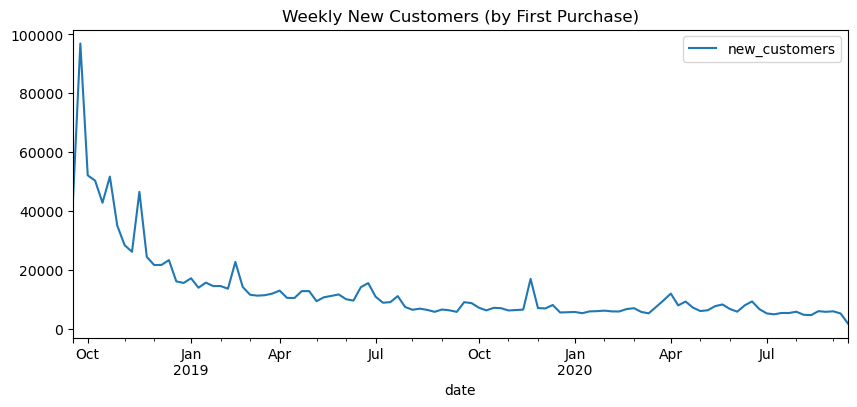

In [82]:
newbie_daily = (first_tx
                .assign(date=lambda x: x["first_purchase_date"].dt.to_period("W").dt.start_time)
                .groupby("date")["customer_id"].nunique()
                .reset_index(name="new_customers"))

newbie_daily.plot(x="date", y="new_customers", kind="line", figsize=(10,4), title="Weekly New Customers (by First Purchase)")

# 2. 신규고객 이탈 (첫날 이후 구매가 없는 고객)

In [83]:
# 거래 및 거래가 1번밖에 없는 사람은 신규고객 이탈
purchase_counts = EDA_columns['customer_id'].value_counts()

# 라벨링: 구매 1회 → 1, 그 외 → 0
churn_label = pd.DataFrame({
    'customer_id': purchase_counts.index,
    '신규고객이탈': (purchase_counts == 1).astype(int)  # 이탈 → 1, 미이탈 → 0
})
churn_label = churn_label.reset_index(drop=True)
churn_label

,customer_id,신규고객이탈
0,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,0
1,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,0
2,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,0
3,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,0
4,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,0
...,...,...
1356222,489365763889a4ab465c21442ec4918bd1ad338269cd8a...,1
1356223,48932bbd8eececf5dd3fef971841c9c46138ec3c156c71...,1
1356224,d13fb513cd09af4a0b29a0d13014dfe173e0b8045840c8...,1
1356225,d13fd35252cfaa287f267ca5feb6cb8947dda8d55d5a35...,1


In [29]:
### 메모리 부족으로 인한 타입변경


# API_count['total_churn'] = API_count['total_churn'].astype(np.int8)
# churn_label['신규고객이탈'] = churn_label['신규고객이탈'].astype(np.int8)
# EDA_columns['customer_id'] = EDA_columns['customer_id'].astype('category')
# API_count['customer_id'] = API_count['customer_id'].astype('category')
# churn_label['customer_id'] = churn_label['customer_id'].astype('category')

In [84]:
# 전체 고객 이탈 라벨링 데이터를 EDA df에 merge (0:미이탈 / 1:이탈)
API_merge = API_count[['customer_id','API ratio','total_churn']]
API_churn_label_merge = EDA_columns.merge(API_merge,on=['customer_id'],how='left')

# 신규 고객 이탈 라벨링 데이터를 EDA df에 merge (0:미이탈 / 1:이탈)
first_customer_merge = churn_label[['customer_id','신규고객이탈']]
API_churn_label_merge = API_churn_label_merge.merge(first_customer_merge,on=['customer_id'],how='left' )
API_churn_label_merge

,customer_id,FN,club_member_status,fashion_news_frequency,age,t_dat,price,product_group_name,age_cut,transaction_dat,prev_date,gap,API ratio,total_churn,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,30대,2018-12-27,0,0.0,68.666667,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,30대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,30대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,30대,2019-05-02,2018-12-27 00:00:00,126.0,68.666667,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대,2019-05-25,2019-05-02 00:00:00,23.0,68.666667,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31726154,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.043203,Garment Full body,10대 미만,2020-04-09,2020-04-05 00:00:00,4.0,26.000000,0,0
31726155,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-09,0.013542,Garment Upper body,10대 미만,2020-04-09,2020-04-09 00:00:00,0.0,26.000000,0,0
31726156,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-04-25,0.050831,Garment Full body,10대 미만,2020-04-25,2020-04-09 00:00:00,16.0,26.000000,0,0
31726157,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,ACTIVE,Regularly,18.0,2020-06-22,0.016932,Underwear,10대 미만,2020-06-22,2020-04-25 00:00:00,58.0,26.000000,0,0


In [85]:
API_churn_label_merge[API_churn_label_merge['customer_id']=='ffffd9ac14e89946416d80e791d064701994755c3ab686a1eaf3458c36f52241']

,customer_id,FN,club_member_status,fashion_news_frequency,age,t_dat,price,product_group_name,age_cut,transaction_dat,prev_date,gap,API ratio,total_churn,신규고객이탈
31726158,ffffd9ac14e89946416d80e791d064701994755c3ab686...,0.0,PRE-CREATE,NONE,65.0,2019-12-04,0.084729,Shoes,50대,2019-12-04,0,0.0,0.0,1,1


In [87]:
API_churn_label_merge.columns

Index(['customer_id', 'FN', 'club_member_status', 'fashion_news_frequency',
       'age', 't_dat', 'price', 'product_group_name', 'age_cut',
       'transaction_dat', 'prev_date', 'gap', 'API ratio', 'total_churn',
       '신규고객이탈'],
      dtype='object')

In [92]:
col_kr_map = {
    'customer_id': '고객ID',
    'churn': '이탈여부',  # 0: 잔존, 1: 이탈
    'FN': '패션뉴스구독 여부',  # 패션뉴스구독 여부
    'club_member_status': '멤버십상태',  # ACTIVE, PRE-CREATE, LEFT CLUB
    'fashion_news_frequency': '뉴스레터수신빈도',  # NONE, Monthly, Regularly
    'age': '연령',
    't_dat': '구매일',  # 거래/주문 날짜
    'price': '구매금액',
    'product_group_name': '상품그룹',
    'age_cut': '연령대',
    'prev_date': '이전구매일',  # 이전 구매 날짜
    'gap': '구매간격(일)',  # 현재-이전 구매일 차이
    'total_churn': '전체고객이탈여부'  # 전체고객 기준 이탈/미이탈

}

# 컬럼명 변경
API_churn_label_merge.rename(columns=col_kr_map, inplace=True)

# 확인
API_churn_label_merge.head(50)

,고객ID,패션뉴스구독 여부,멤버십상태,뉴스레터수신빈도,연령,구매일,구매금액,상품그룹,연령대,transaction_dat,이전구매일,구매간격(일),API ratio,전체고객이탈여부,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,30대,2018-12-27,0,0.0,68.666667,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,30대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,30대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,30대,2019-05-02,2018-12-27 00:00:00,126.0,68.666667,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대,2019-05-25,2019-05-02 00:00:00,23.0,68.666667,0,0
5,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,30대,2019-05-25,2019-05-25 00:00:00,0.0,68.666667,0,0
6,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-07-25,0.012695,Garment Upper body,30대,2019-07-25,2019-05-25 00:00:00,61.0,68.666667,0,0
7,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-07-25,0.021169,Garment Lower body,30대,2019-07-25,2019-07-25 00:00:00,0.0,68.666667,0,0
8,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-09-18,0.044051,Garment Lower body,30대,2019-09-18,2019-07-25 00:00:00,55.0,68.666667,0,0
9,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-09-28,0.054220,Garment Upper body,30대,2019-09-28,2019-09-18 00:00:00,10.0,68.666667,0,0


In [109]:
API_churn_label_merge.to_csv(
    r"C:\Users\Playdata\src\jjha\data\final_EDA_df.csv",
    index=False
)

In [110]:
# 고객별 first_purchase_date를 transactions에 붙임 (merge는 부담이지만 컬럼 1개라 괜찮음)
tx = transactions.merge(first_tx, on="customer_id", how="left")

tx["days_from_first"] = (tx["t_dat"] - tx["first_purchase_date"]).dt.days

# label window: 30~119일 구매 횟수
tx["in_label_window"] = (tx["days_from_first"] >= 30) & (tx["days_from_first"] < 120)

label_cnt = (tx.loc[tx["in_label_window"]]
               .groupby("customer_id")["article_id"]
               .size()
               .reset_index(name="purchases_30_120"))

In [112]:
data = cust.merge(label_cnt, on="customer_id", how="left")
data["purchases_30_120"] = data["purchases_30_120"].fillna(0).astype("int32")

# 이탈: 30~120일 구매가 0
data["label_churn"] = (data["purchases_30_120"] == 0).astype("int8")

In [113]:
data["label_churn"].value_counts(normalize=True)

label_churn
1    0.60594
0    0.39406
Name: proportion, dtype: float64

In [114]:
cat_cols = ["club_member_status", "fashion_news_frequency"]
bin_cols = ["FN", "Active"]

for c in cat_cols:
    data[c] = data[c].fillna("UNKNOWN").astype("string")

for b in bin_cols:
    if b in data.columns:
        data[b] = data[b].fillna(0).astype("int8")

# 원핫
X_cat = pd.get_dummies(data[cat_cols], drop_first=True)

In [44]:
churn_rate = data["label_churn"].mean()
churn_rate

np.float64(0.6059403198297352)

# 온라인 구매비율에 따른 이탈 차이분석

In [116]:
# 날짜형 변환
tx["t_dat"] = pd.to_datetime(tx["t_dat"])
tx["first_purchase_date"] = pd.to_datetime(tx["first_purchase_date"])

# 초기구매 여부
tx["purchase_type"] = (
    tx["t_dat"] == tx["first_purchase_date"]
).map({True: "초기구매", False: "이후구매"})

In [118]:
cust_channel = (
    tx.groupby(["customer_id", "purchase_type", "sales_channel_id"])
      .size()
      .unstack(fill_value=0)
)

cust_channel["online_ratio"] = (
    cust_channel.get(2, 0) /
    (cust_channel.sum(axis=1) + 1e-9)
)

cust_channel = cust_channel.reset_index()

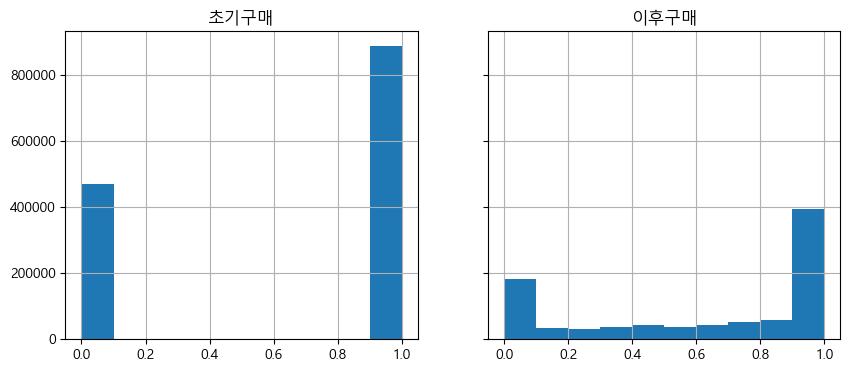

In [120]:
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)

cust_channel[cust_channel["purchase_type"]=="초기구매"]["online_ratio"] \
    .hist(bins=10, ax=axes[0])
axes[0].set_title("초기구매")

cust_channel[cust_channel["purchase_type"]=="이후구매"]["online_ratio"] \
    .hist(bins=10, ax=axes[1])
axes[1].set_title("이후구매")

plt.show()

# 코호트 이탈률=해당 주차에 첫 구매한 고객들의 평균 churn 값

In [128]:
data["purchases_30_120"]

0          0
1          1
2          0
3          0
4          0
          ..
1371975    4
1371976    4
1371977    7
1371978    1
1371979    0
Name: purchases_30_120, Length: 1371980, dtype: int32

In [129]:
data["purchases_30_120"].value_counts()

purchases_30_120
0      831338
2       75051
1       72811
3       60759
4       51589
        ...  
154         1
207         1
169         1
210         1
130         1
Name: count, Length: 181, dtype: int64

In [124]:
data["고객구분"] = data["purchases_30_120"].apply(
    lambda x: "신규고객" if x == 0 else "재구매고객"
)

In [130]:
data["고객구분"] = data["purchases_30_120"].apply(
    lambda x: "신규고객" if x == 0 else "재구매고객"
)

In [131]:
print(data.columns)

Index(['customer_id', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code', 'first_purchase_date',
       'purchases_30_120', 'label_churn', '고객구분'],
      dtype='object')


In [132]:
data["first_purchase_date"] = pd.to_datetime(data["first_purchase_date"])

In [147]:
data["고객구분"] = data["purchases_30_120"].apply(
    lambda x: "신규고객" if x == 0 else "재구매고객"
)

In [148]:
data["is_new_customer"] = (data["purchases_30_120"] == 0).astype(int)

In [149]:
cohort_new = (
    data[data["is_new_customer"] == 1]
        .dropna(subset=["first_purchase_date"])
        .assign(코호트주=lambda x: x["first_purchase_date"]
                .dt.to_period("W").dt.start_time)
        .groupby("코호트주")["label_churn"]
        .mean()
        .reset_index()
)

In [150]:
tx["t_dat"] = pd.to_datetime(tx["t_dat"])

last_purchase = (
    tx.groupby("customer_id")["t_dat"]
      .max()
      .reset_index()
      .rename(columns={"t_dat": "last_purchase_date"})
)

data = data.merge(last_purchase, on="customer_id", how="left")

In [151]:
analysis_date = tx["t_dat"].max()

In [153]:
last_purchase = (
    tx.groupby("customer_id")["t_dat"]
    .max()
    .reset_index()
    .rename(columns={"t_dat": "last_purchase_date"})
)

data = data.merge(last_purchase, on="customer_id", how="left")

In [155]:
analysis_date = tx["t_dat"].max()

In [164]:
# last_purchase_date 생성 (merge 없이)
data["last_purchase_date"] = (
    tx.groupby("customer_id")["t_dat"]
    .transform("max")
)

analysis_date = tx["t_dat"].max()

# recency 계산
data["recency_days"] = (
    analysis_date - data["last_purchase_date"]
).dt.days

# 90일 이탈 정의
data["label_churn_90"] = (data["recency_days"] >= 90).astype(int)

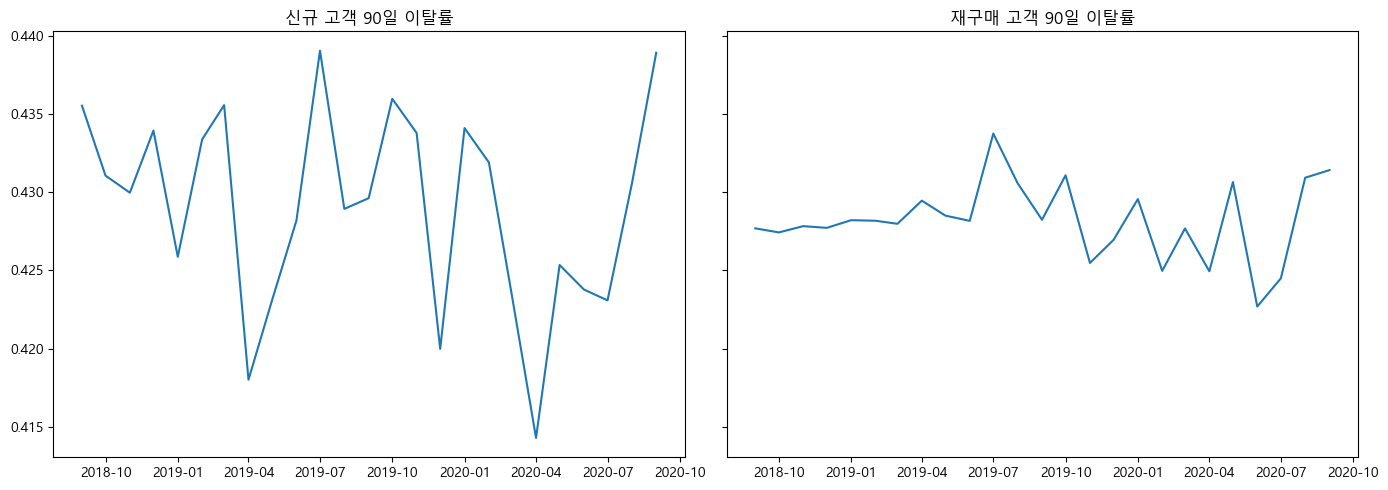

In [165]:
cohort_new = (
    data[data["고객구분"]=="신규고객"]
    .assign(코호트월=lambda x: x["first_purchase_date"]
            .dt.to_period("M").dt.start_time)
    .groupby("코호트월")["label_churn_90"]
    .mean()
    .reset_index()
)

cohort_repeat = (
    data[data["고객구분"]=="재구매고객"]
    .assign(코호트월=lambda x: x["first_purchase_date"]
            .dt.to_period("M").dt.start_time)
    .groupby("코호트월")["label_churn_90"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(14,5), sharey=True)

axes[0].plot(cohort_new["코호트월"], cohort_new["label_churn_90"])
axes[0].set_title("신규 고객 90일 이탈률")

axes[1].plot(cohort_repeat["코호트월"], cohort_repeat["label_churn_90"])
axes[1].set_title("재구매 고객 90일 이탈률")

plt.tight_layout()
plt.show()

# 회원 상태별 이탈률=해당그룹의label_churn평균

In [166]:
data.rename(columns=col_kr_map, inplace=True)

In [167]:
print(data.columns)

Index(['고객ID', '패션뉴스구독 여부', 'Active', '멤버십상태', '뉴스레터수신빈도', '연령', 'postal_code',
       'first_purchase_date', 'purchases_30_120', 'label_churn', '고객구분',
       'is_new_customer', 'last_purchase_date_x', 'recency_days',
       'label_churn_90', 'last_purchase_date_y', 'last_purchase_date',
       'total_purchases'],
      dtype='object')


In [168]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 한글폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

In [171]:
print(data.columns)

Index(['고객ID', '패션뉴스구독 여부', 'Active', '멤버십상태', '뉴스레터수신빈도', '연령', 'postal_code',
       'first_purchase_date', 'purchases_30_120', 'label_churn', '고객구분',
       'is_new_customer', 'last_purchase_date_x', 'recency_days',
       'label_churn_90', 'last_purchase_date_y', 'last_purchase_date',
       'total_purchases'],
      dtype='object')


In [172]:
status_map = {
    "PRE-CREATE": "가입전",
    "UNKNOWN": "미확인",
    "LEFT CLUB": "탈퇴",
    "ACTIVE": "활성회원"
}

data["멤버십상태_한글"] = data["멤버십상태"].map(status_map)

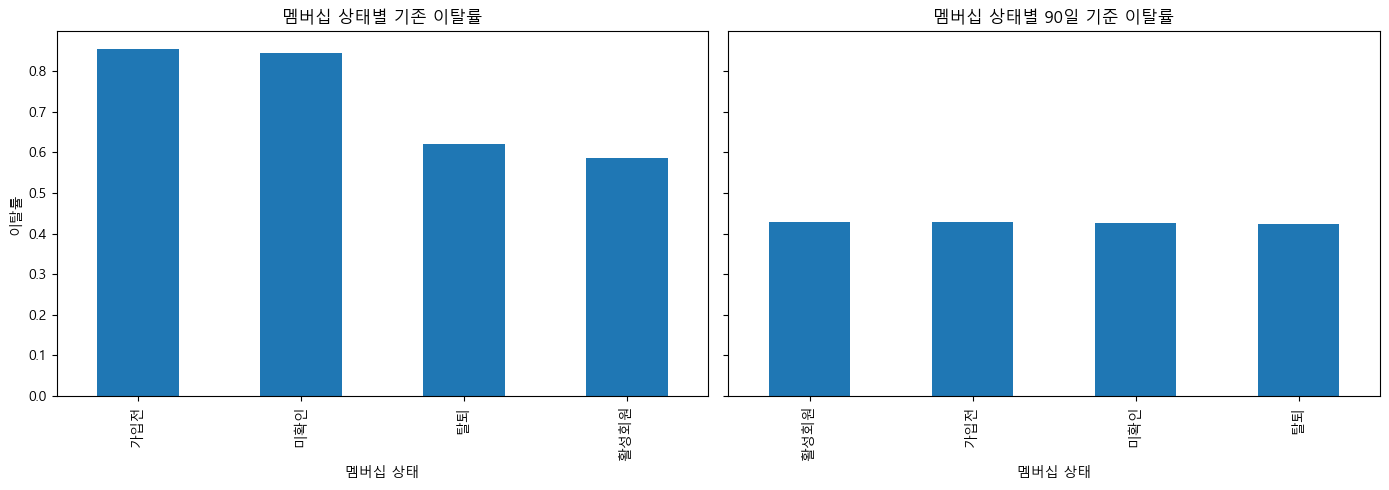

In [173]:
import matplotlib.pyplot as plt

# 기존 이탈
churn_old = (
    data.groupby("멤버십상태_한글")["label_churn"]
    .mean()
    .sort_values(ascending=False)
)

# 90일 이탈
churn_90 = (
    data.groupby("멤버십상태_한글")["label_churn_90"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

churn_old.plot(kind="bar", ax=axes[0])
axes[0].set_title("멤버십 상태별 기존 이탈률")
axes[0].set_xlabel("멤버십 상태")
axes[0].set_ylabel("이탈률")

churn_90.plot(kind="bar", ax=axes[1])
axes[1].set_title("멤버십 상태별 90일 기준 이탈률")
axes[1].set_xlabel("멤버십 상태")

plt.tight_layout()
plt.show()

# 뉴스 수신 빈도별 이탈률=해당그룹의churn평균

In [175]:
news_map = {
    "NONE": "수신안함",
    "Monthly": "월간수신",
    "Regularly": "정기수신",
    "UNKNOWN": "미확인"
}

data["뉴스레터빈도_한글"] = data["뉴스레터수신빈도"].map(news_map)

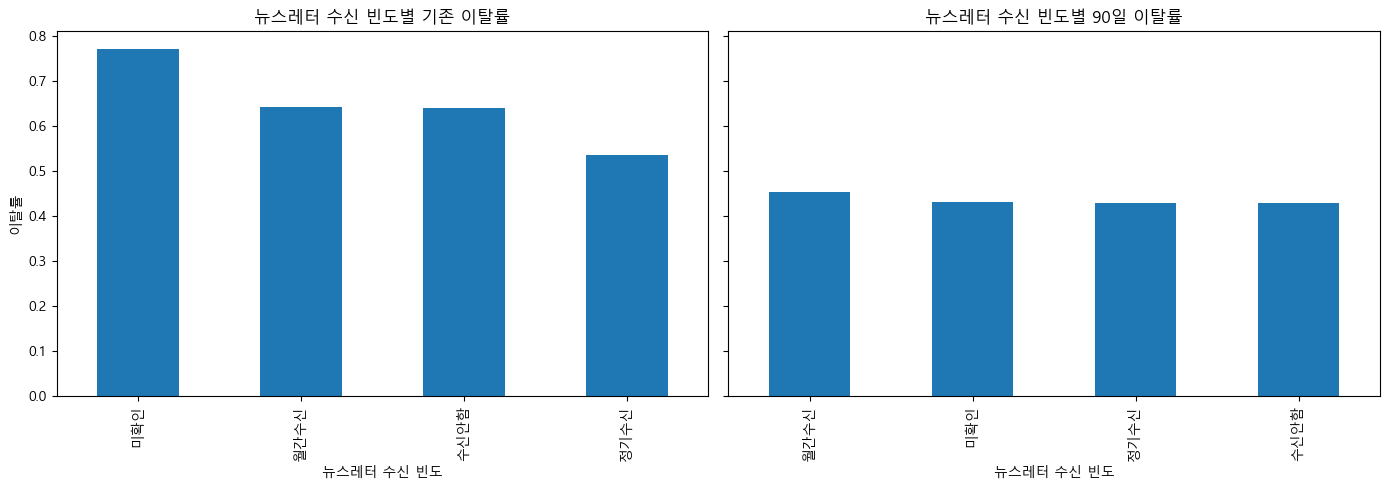

In [177]:
import matplotlib.pyplot as plt

# 기존 이탈
nf_old = (
    data.groupby("뉴스레터빈도_한글")["label_churn"]
    .mean()
    .sort_values(ascending=False)
)

# 90일 이탈
nf_90 = (
    data.groupby("뉴스레터빈도_한글")["label_churn_90"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

nf_old.plot(kind="bar", ax=axes[0])
axes[0].set_title("뉴스레터 수신 빈도별 기존 이탈률")
axes[0].set_xlabel("뉴스레터 수신 빈도")
axes[0].set_ylabel("이탈률")

nf_90.plot(kind="bar", ax=axes[1])
axes[1].set_title("뉴스레터 수신 빈도별 90일 이탈률")
axes[1].set_xlabel("뉴스레터 수신 빈도")

plt.tight_layout()
plt.show()

# (Active, FN 조합별 평균 churn)

In [179]:
pivot = pd.pivot_table(
    data,
    values="label_churn",
    index="Active",
    columns="패션뉴스구독 여부",
    aggfunc="mean"
)

pivot

패션뉴스구독 여부,0,1
Active,,
0,0.642891,0.699984
1,NaN,0.532187


# purchases_0_30=첫구매후30일동안구매횟수

In [182]:
print(tx.columns)

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id',
       'first_purchase_date', 'days_from_first', 'in_label_window',
       'purchase_type', 'in_first_30'],
      dtype='object')


In [183]:
# 0~30일 구매 여부
tx["in_first_30"] = (tx["days_from_first"] >= 0) & (tx["days_from_first"] < 30)

first30 = (
    tx.loc[tx["in_first_30"]]
      .groupby("customer_id")
      .size()
      .reset_index(name="초기30일구매횟수")
)

In [184]:
tmp2 = (
    data.merge(first30,
               left_on="고객ID",
               right_on="customer_id",
               how="left")
        .fillna({"초기30일구매횟수": 0})
)

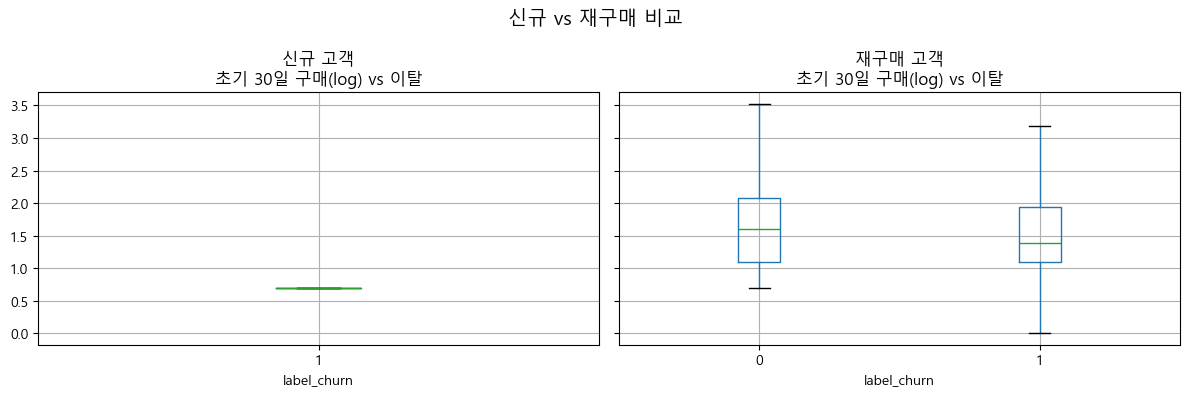

In [186]:
import numpy as np
import matplotlib.pyplot as plt

tmp2["log_초기30일구매"] = np.log1p(tmp2["초기30일구매횟수"])

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# 신규
tmp2[tmp2["고객구분"]=="신규고객"] \
    .boxplot(column="log_초기30일구매",
             by="label_churn",
             ax=axes[0],
             showfliers=False)

axes[0].set_title("신규 고객\n초기 30일 구매(log) vs 이탈")

# 재구매
tmp2[tmp2["고객구분"]=="재구매고객"] \
    .boxplot(column="log_초기30일구매",
             by="label_churn",
             ax=axes[1],
             showfliers=False)

axes[1].set_title("재구매 고객\n초기 30일 구매(log) vs 이탈")

plt.suptitle("신규 vs 재구매 비교", fontsize=14)
plt.tight_layout()
plt.show()

# 첫 30일 평균 구매단가(avg_price_0_30)

In [188]:
# 0~30일 평균 구매금액
first30_price = (
    tx.loc[tx["in_first_30"]]
      .groupby("customer_id")["price"]
      .mean()
      .reset_index(name="avg_price_0_30")
)

# 고객ID로 merge (컬럼명 통일!)
first30_price = first30_price.rename(columns={"customer_id": "고객ID"})

tmp3 = (
    data.merge(first30_price, on="고객ID", how="left")
        .fillna({"avg_price_0_30": 0})
)

In [195]:
new = tmp3[tmp3["고객구분"] == "신규고객"].copy()
repeat = tmp3[tmp3["고객구분"] == "재구매고객"].copy()

In [196]:
print(tmp3.columns)

Index(['고객ID', '패션뉴스구독 여부', 'Active', '멤버십상태', '뉴스레터수신빈도', '연령', 'postal_code',
       'first_purchase_date', 'purchases_30_120', 'label_churn', '고객구분',
       'is_new_customer', 'last_purchase_date_x', 'recency_days',
       'label_churn_90', 'last_purchase_date_y', 'last_purchase_date',
       'total_purchases', '멤버십상태_한글', '뉴스레터빈도_한글', 'avg_price_0_30'],
      dtype='object')


C:\Users\Playdata\AppData\Local\Temp\ipykernel_19844\2921426215.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19844\2921426215.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default

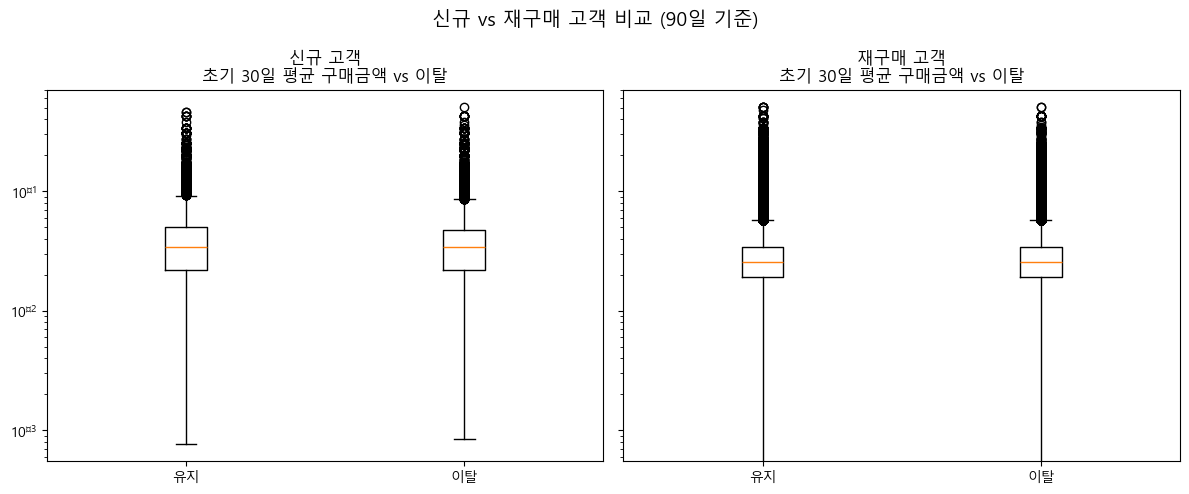

In [199]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# 신규 고객
axes[0].boxplot(
    [
        new[new["label_churn_90"]==0]["avg_price_0_30"],
        new[new["label_churn_90"]==1]["avg_price_0_30"]
    ],
    labels=["유지", "이탈"]
)
axes[0].set_title("신규 고객\n초기 30일 평균 구매금액 vs 이탈")
axes[0].set_yscale("log")

# 재구매 고객
axes[1].boxplot(
    [
        repeat[repeat["label_churn_90"]==0]["avg_price_0_30"],
        repeat[repeat["label_churn_90"]==1]["avg_price_0_30"]
    ],
    labels=["유지", "이탈"]
)
axes[1].set_title("재구매 고객\n초기 30일 평균 구매금액 vs 이탈")
axes[1].set_yscale("log")

plt.suptitle("신규 vs 재구매 고객 비교 (90일 기준)", fontsize=14)
plt.tight_layout()
plt.show()

In [198]:
q = tmp3["avg_price_0_30"].quantile(0.99)

new_cut = new[new["avg_price_0_30"] <= q]
repeat_cut = repeat[repeat["avg_price_0_30"] <= q]

# log 변환

In [203]:
import numpy as np

tmp3["log_price"] = np.log1p(tmp3["avg_price_0_30"])

In [204]:
print("log_price" in tmp3.columns)

True


In [206]:
new = tmp3[tmp3["고객구분"] == "신규고객"].copy()
repeat = tmp3[tmp3["고객구분"] == "재구매고객"].copy()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_19844\430452919.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19844\430452919.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


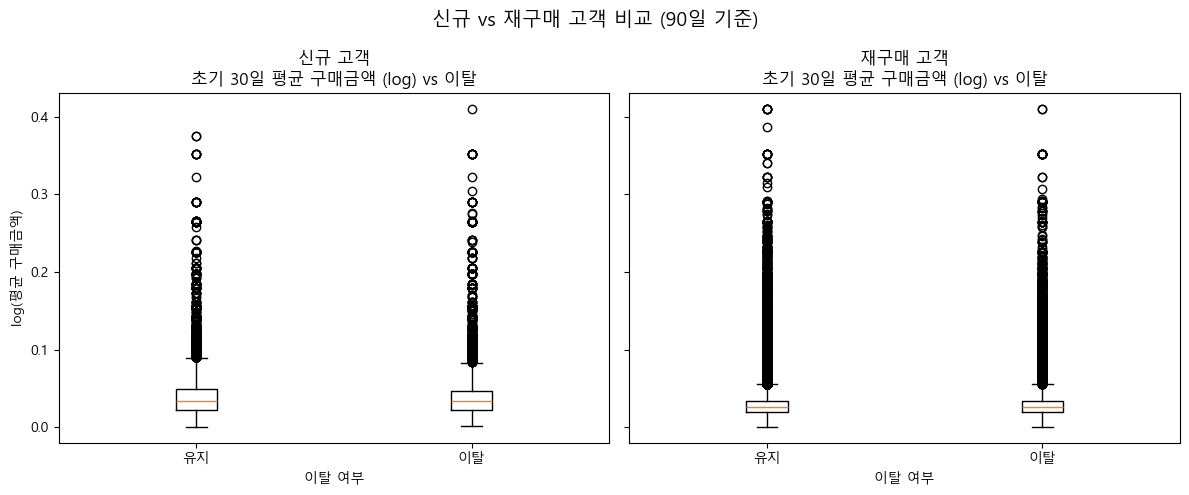

In [207]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# 신규 고객
axes[0].boxplot(
    [
        new[new["label_churn_90"]==0]["log_price"],
        new[new["label_churn_90"]==1]["log_price"]
    ],
    labels=["유지", "이탈"]
)
axes[0].set_title("신규 고객\n초기 30일 평균 구매금액 (log) vs 이탈")
axes[0].set_xlabel("이탈 여부")
axes[0].set_ylabel("log(평균 구매금액)")

# 재구매 고객
axes[1].boxplot(
    [
        repeat[repeat["label_churn_90"]==0]["log_price"],
        repeat[repeat["label_churn_90"]==1]["log_price"]
    ],
    labels=["유지", "이탈"]
)
axes[1].set_title("재구매 고객\n초기 30일 평균 구매금액 (log) vs 이탈")
axes[1].set_xlabel("이탈 여부")

plt.suptitle("신규 vs 재구매 고객 비교 (90일 기준)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
final_df = data.merge(first30, on="customer_id", how="left")
final_df = final_df.merge(first30_price, on="customer_id", how="left")

final_df["purchases_0_30"] = final_df["purchases_0_30"].fillna(0)
final_df["avg_price_0_30"] = final_df["avg_price_0_30"].fillna(0)

# 최근 소비 행동 + 활동 여부 기반 이탈 예측 모델

In [ ]:
features = ["purchases_0_30", "avg_price_0_30", "FN", "Active"]

X = final_df[features]
y = final_df["label_churn"]

In [ ]:
features = ["purchases_0_30", "FN", "Active"]

X = tmp2[features]
y = tmp2["label_churn"]

In [ ]:
final_df.columns

Index(['customer_id', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code', 'first_purchase_date',
       'purchases_30_120', 'label_churn', 'purchases_0_30', 'avg_price_0_30'],
      dtype='object')

In [ ]:
features = [
    "purchases_0_30",
    "avg_price_0_30",
    "FN",
    "Active"
]

X = final_df[features].fillna(0)
y = final_df["label_churn"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

pred_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred_prob)

0.6212722481986059

In [ ]:
final_df["churn_prob"] = model.predict_proba(X)[:,1]

In [ ]:
threshold = final_df["churn_prob"].quantile(0.90)
high_risk = final_df[final_df["churn_prob"] >= threshold]

In [ ]:
print("전체 평균")
print(final_df[features].mean())

print("\n고위험 고객 평균")
print(high_risk[features].mean())

전체 평균
purchases_0_30    4.820451
avg_price_0_30    0.030218
FN                0.347622
Active            0.338492
dtype: float64

고위험 고객 평균
purchases_0_30    0.951796
avg_price_0_30    0.042423
FN                0.060747
Active            0.023623
dtype: float64


In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)

purchases_0_30    0.604040
Active            0.151648
avg_price_0_30    0.150768
FN                0.093544
dtype: float64

In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

purchases_0_30    0.604040
Active            0.151648
avg_price_0_30    0.150768
FN                0.093544
dtype: float64

In [ ]:
total_budget = 100_000_000  # 1억

budget_allocation = (importance / importance.sum()) * total_budget
budget_allocation

purchases_0_30    6.040403e+07
Active            1.516479e+07
avg_price_0_30    1.507680e+07
FN                9.354383e+06
dtype: float64

In [ ]:
high_risk_count = len(high_risk)
coupon_cost = 5000
avg_revenue = 40000
uplift = 0.15

expected_extra_revenue = high_risk_count * uplift * avg_revenue
total_coupon_cost = high_risk_count * coupon_cost

roi = (expected_extra_revenue - total_coupon_cost) / total_coupon_cost

expected_extra_revenue, total_coupon_cost, roi

(890220000.0, 741850000, 0.2)

In [ ]:
!pip install shap

In [ ]:
# X_test가 너무 크면 샘플링 (필수)
X_test_s = X_test.sample(n=min(5000, len(X_test)), random_state=42)
X_train_s = X_train.sample(n=min(5000, len(X_train)), random_state=42)

In [ ]:
print(np.array(sv).shape)

(5000, 4, 2)


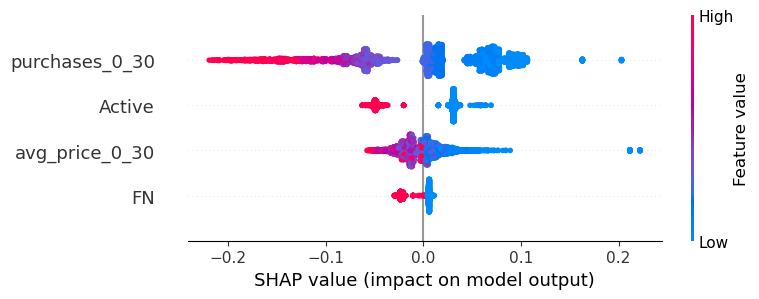

In [ ]:
sv_class1 = sv[1] if isinstance(sv, list) else sv[:, :, 1]

shap.summary_plot(sv_class1, X_test_s)

SHAP shape: (5000, 4)
X shape: (5000, 4)


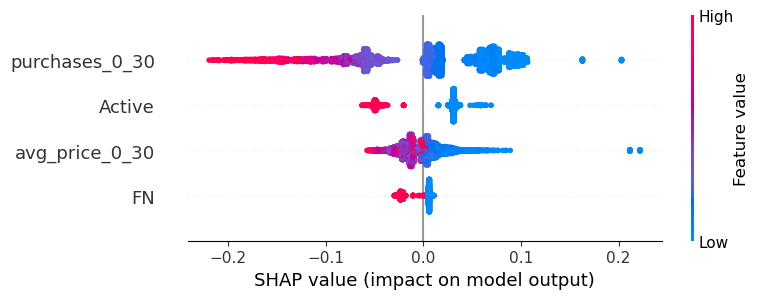

In [ ]:
import numpy as np
import shap

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test_s, check_additivity=False)

# --- 구조 자동 처리 ---
if isinstance(sv, list):
    sv_plot = sv[1]   # class 1
else:
    sv_array = np.array(sv)
    if sv_array.ndim == 3:
        sv_plot = sv_array[:, :, 1]   # 마지막 차원 class=1
    else:
        sv_plot = sv_array

print("SHAP shape:", sv_plot.shape)
print("X shape:", X_test_s.shape)

shap.summary_plot(sv_plot, X_test_s)

<Axes: >

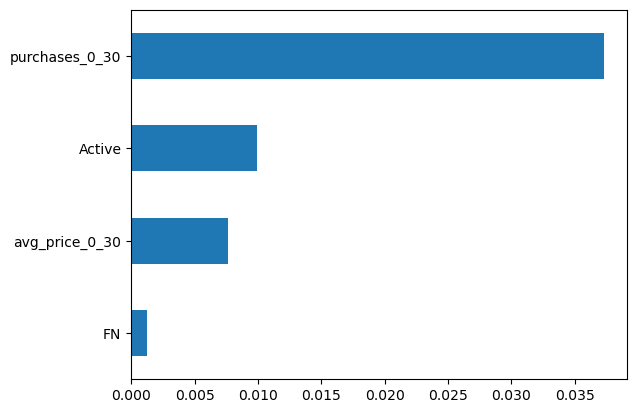

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
pd.Series(r.importances_mean, index=X_test.columns).sort_values().plot(kind="barh")

In [ ]:
transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])

last_purchase = (
    transactions
    .groupby("customer_id")["t_dat"]
    .max()
    .reset_index()
)

last_purchase.columns = ["customer_id", "last_purchase_date"]

In [ ]:
reference_date = transactions["t_dat"].max()

In [ ]:
last_purchase["recency"] = (
    reference_date - last_purchase["last_purchase_date"]
).dt.days

In [ ]:
final_df = final_df.merge(
    last_purchase[["customer_id", "recency"]],
    on="customer_id",
    how="left"
)

final_df["recency"] = final_df["recency"].fillna(999)

In [ ]:
reference_date = transactions["t_dat"].max()

last_purchase = (transactions.groupby("customer_id")["t_dat"]
                 .max().reset_index(name="last_purchase_date"))

last_purchase["recency"] = (reference_date - last_purchase["last_purchase_date"]).dt.days
last_purchase["label_churn_recency90"] = (last_purchase["recency"] >= 90).astype("int8")

In [ ]:
# 1) first_purchase_date
first_tx = (transactions.groupby("customer_id")["t_dat"]
            .min().reset_index(name="first_purchase_date"))

tx = transactions.merge(first_tx, on="customer_id", how="left")
tx["days_from_first"] = (tx["t_dat"] - tx["first_purchase_date"]).dt.days

# 2) label window (30~120)
in_label = tx[(tx["days_from_first"] >= 30) & (tx["days_from_first"] < 120)]

cnt = (in_label.groupby("customer_id").size()
       .reset_index(name="purchases_30_120"))

label_df = first_tx.merge(cnt, on="customer_id", how="left")
label_df["purchases_30_120"] = label_df["purchases_30_120"].fillna(0).astype("int32")
label_df["label_churn"] = (label_df["purchases_30_120"] == 0).astype("int8")

In [ ]:
transactions["t_dat"].dtype

dtype('<M8[ns]')

In [ ]:
transactions["t_dat"].max()
transactions["t_dat"].min()

Timestamp('2018-09-20 00:00:00')

In [ ]:
# 1. 기준일을 과거로 설정
reference_date = pd.to_datetime("2020-06-01")

# 2. 고객별 마지막 구매일
last_purchase = (
    transactions
    .groupby("customer_id")["t_dat"]
    .max()
    .reset_index()
)

last_purchase.columns = ["customer_id", "last_purchase_date"]

# 3. recency 계산
last_purchase["recency"] = (
    reference_date - last_purchase["last_purchase_date"]
).dt.days

# 4. label
last_purchase["label_churn"] = (last_purchase["recency"] >= 90).astype(int)

print(last_purchase["label_churn"].value_counts())
print(last_purchase["recency"].describe())

label_churn
0    774197
1    588084
Name: count, dtype: int64
count    1.362281e+06
mean     1.221484e+02
std      2.211188e+02
min     -1.130000e+02
25%     -6.500000e+01
50%      3.800000e+01
75%      2.850000e+02
max      6.200000e+02
Name: recency, dtype: float64


In [ ]:
transactions_filtered = transactions[
    transactions["t_dat"] <= reference_date
]

In [ ]:
last_purchase = last_purchase[last_purchase["recency"] >= 0]

In [ ]:
from xgboost import XGBClassifier

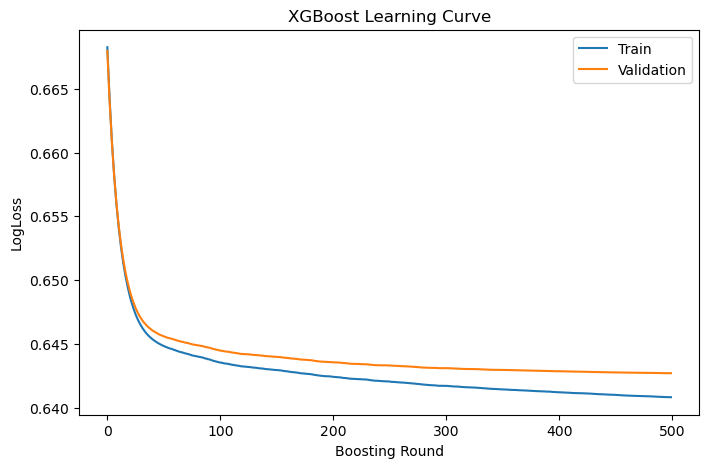

In [ ]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"   # 여기로 이동
)

xgb_clf.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

result = xgb_clf.evals_result()

plt.figure(figsize=(8,5))
plt.plot(result['validation_0']['logloss'], label='Train')
plt.plot(result['validation_1']['logloss'], label='Validation')
plt.legend()
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.title('XGBoost Learning Curve')
plt.show()

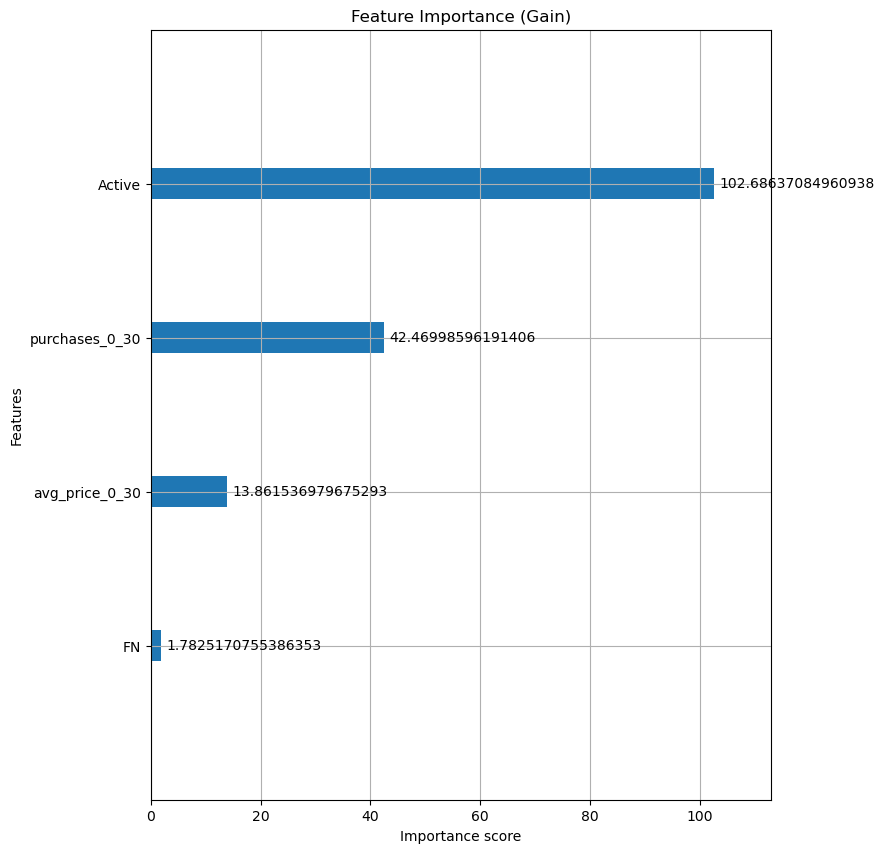

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,10))
plot_importance(xgb_clf, importance_type="gain", ax=ax)
plt.title("Feature Importance (Gain)")
plt.show()